## 1.0. EDA

## Data loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px

In [6]:
def read_data(file_path):
    data = pd.read_csv(file_path, sep=';', decimal=',')
    data['Fecha'] = pd.to_datetime(data['Fecha'], format='%d/%m/%Y %H:%M')
    grid_mapping = {
        '0': 0,
        'A1': 1,
        'A2': 2,
        'A3': 3,
        'B1': 4,
        'B2': 5,
        'B3': 6,
        'C1': 7,
        'C2': 8,
        'C3': 9
    }
    data['Cuadricula'] = data['Cuadricula'].map(grid_mapping)
    return data

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath='1_RMS_600.csv'

In [9]:
data = read_data(filepath)

In [10]:
data.tail()

,Cuadricula,Peso,Fecha,Sigma0,Sigma1,Sigma2,Sigma3,Sigma4,Sigma5,Sigma6,...,Sigma14,Sigma15,Sigma16,Sigma17,Sigma18,Sigma19,Sigma20,Sigma21,Sigma22,Sigma23
987,9,100,2025-01-03 21:30:00,0.023283,0.009585,0.031363,0.029732,0.009806,0.012722,0.009035,...,0.008799,0.016818,0.008185,0.004663,0.006774,0.007621,0.007948,0.009949,0.007657,0.007385
988,9,100,2025-01-03 21:45:00,0.023185,0.009551,0.031064,0.029578,0.009770,0.012632,0.009026,...,0.008972,0.016721,0.008142,0.004726,0.006722,0.007583,0.008099,0.009865,0.007622,0.007495
989,9,100,2025-01-03 22:00:00,0.024112,0.009871,0.031116,0.030829,0.010112,0.012660,0.009308,...,0.006015,0.016639,0.008232,0.004075,0.006766,0.007671,0.006004,0.009889,0.007712,0.004766
990,9,100,2025-01-03 22:15:00,0.024985,0.010174,0.030469,0.032039,0.010421,0.012543,0.009625,...,0.008892,0.017777,0.008715,0.005149,0.007123,0.008117,0.007975,0.010539,0.008146,0.007365
991,9,100,2025-01-03 22:30:00,0.023702,0.009752,0.029451,0.030291,0.009986,0.012293,0.009203,...,0.008790,0.016654,0.008197,0.005183,0.006756,0.007644,0.007929,0.009873,0.007676,0.007285


## Descriptive statistics

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Cuadricula  992 non-null    int64         
 1   Peso        992 non-null    int64         
 2   Fecha       992 non-null    datetime64[ns]
 3   Sigma0      992 non-null    float64       
 4   Sigma1      992 non-null    float64       
 5   Sigma2      992 non-null    float64       
 6   Sigma3      992 non-null    float64       
 7   Sigma4      992 non-null    float64       
 8   Sigma5      992 non-null    float64       
 9   Sigma6      992 non-null    float64       
 10  Sigma7      992 non-null    float64       
 11  Sigma8      992 non-null    float64       
 12  Sigma9      992 non-null    float64       
 13  Sigma10     992 non-null    float64       
 14  Sigma11     992 non-null    float64       
 15  Sigma12     992 non-null    float64       
 16  Sigma13     992 non-null  

In [12]:
# Get summary statistics
data.describe()

,Cuadricula,Peso,Fecha,Sigma0,Sigma1,Sigma2,Sigma3,Sigma4,Sigma5,Sigma6,...,Sigma14,Sigma15,Sigma16,Sigma17,Sigma18,Sigma19,Sigma20,Sigma21,Sigma22,Sigma23
count,992.000000,992.000000,992,992.000000,992.000000,992.000000,992.000000,992.000000,992.000000,992.000000,...,992.000000,992.000000,992.000000,992.000000,992.000000,992.000000,992.000000,992.000000,992.000000,992.000000
mean,4.507056,89.817540,2024-12-30 03:50:03.931451904,0.023276,0.009488,0.028942,0.029687,0.009681,0.012037,0.009306,...,0.007238,0.016861,0.007425,0.005078,0.008111,0.006882,0.007100,0.010313,0.006928,0.005733
min,0.000000,0.000000,2024-12-21 09:15:00,0.018765,0.007733,0.020837,0.024073,0.007696,0.008809,0.007628,...,0.004313,0.015251,0.006390,0.003739,0.006511,0.005861,0.005066,0.009252,0.005981,0.003103
25%,2.000000,100.000000,2024-12-25 11:56:15,0.020964,0.008685,0.026853,0.026496,0.008875,0.011465,0.008635,...,0.006953,0.016167,0.007014,0.004646,0.007703,0.006441,0.006795,0.009921,0.006431,0.005193
50%,5.000000,100.000000,2024-12-28 15:07:30,0.022668,0.009405,0.030030,0.029041,0.009605,0.012039,0.009028,...,0.007409,0.016713,0.007410,0.004983,0.007989,0.006894,0.007153,0.010359,0.006934,0.005917
75%,7.000000,100.000000,2025-01-03 07:48:45,0.025582,0.010304,0.031453,0.032640,0.010524,0.013156,0.010273,...,0.007748,0.017510,0.007872,0.005486,0.008584,0.007325,0.007516,0.010642,0.007392,0.006569
max,9.000000,100.000000,2025-01-10 14:45:00,0.029166,0.011471,0.038068,0.037329,0.011779,0.015352,0.011443,...,0.008972,0.019546,0.008715,0.006920,0.010224,0.008117,0.008555,0.011769,0.008146,0.007495
std,2.868450,30.089808,NaN,0.002643,0.000937,0.004294,0.003394,0.000997,0.001321,0.001022,...,0.000876,0.000858,0.000522,0.000590,0.000828,0.000520,0.000638,0.000466,0.000518,0.001087


In [13]:
data['Cuadricula'].value_counts()

,count
Cuadricula,
5,102
1,101
4,101
0,100
7,100
3,100
6,100
8,99
9,98


## Data visualization

### Boxplots

In [14]:
# Create plots for each subtitle
def create_plots(cols, subtitle):
    num_plots = len(cols)
    num_rows = 4  # Rows in the grid
    num_cols_grid = 2  # Columns in the grid

    for i in range(0, num_plots, num_rows * num_cols_grid):
        fig, axes = plt.subplots(num_rows, num_cols_grid, figsize=(16, 8))
        fig.suptitle(f'Box Plots for {subtitle}', fontsize=16)
        axes = axes.ravel()

        for j, col in enumerate(cols[i:i + num_rows * num_cols_grid]):
            sns.boxplot(x='Cuadricula', y=col, data=data, ax=axes[j])
            axes[j].set_title(col)

            # Get the current x-tick positions
            xticks = axes[j].get_xticks()

            # Set the x-ticks explicitly
            axes[j].set_xticks(xticks)

            # Now rotate the labels
            axes[j].set_xticklabels(axes[j].get_xticklabels(), rotation=45, ha='right')

        #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        #plt.subplots_adjust(hspace=0.4, wspace=0.3)
        plt.show()

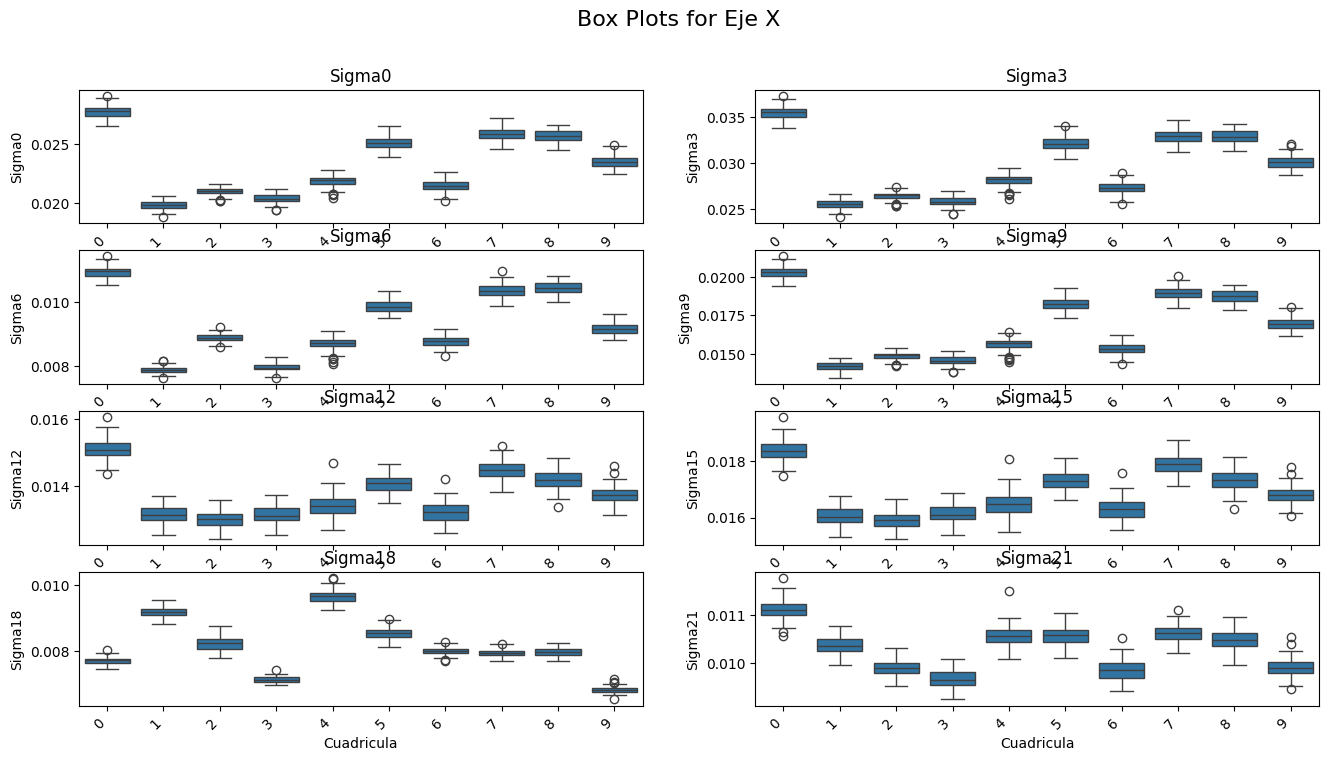

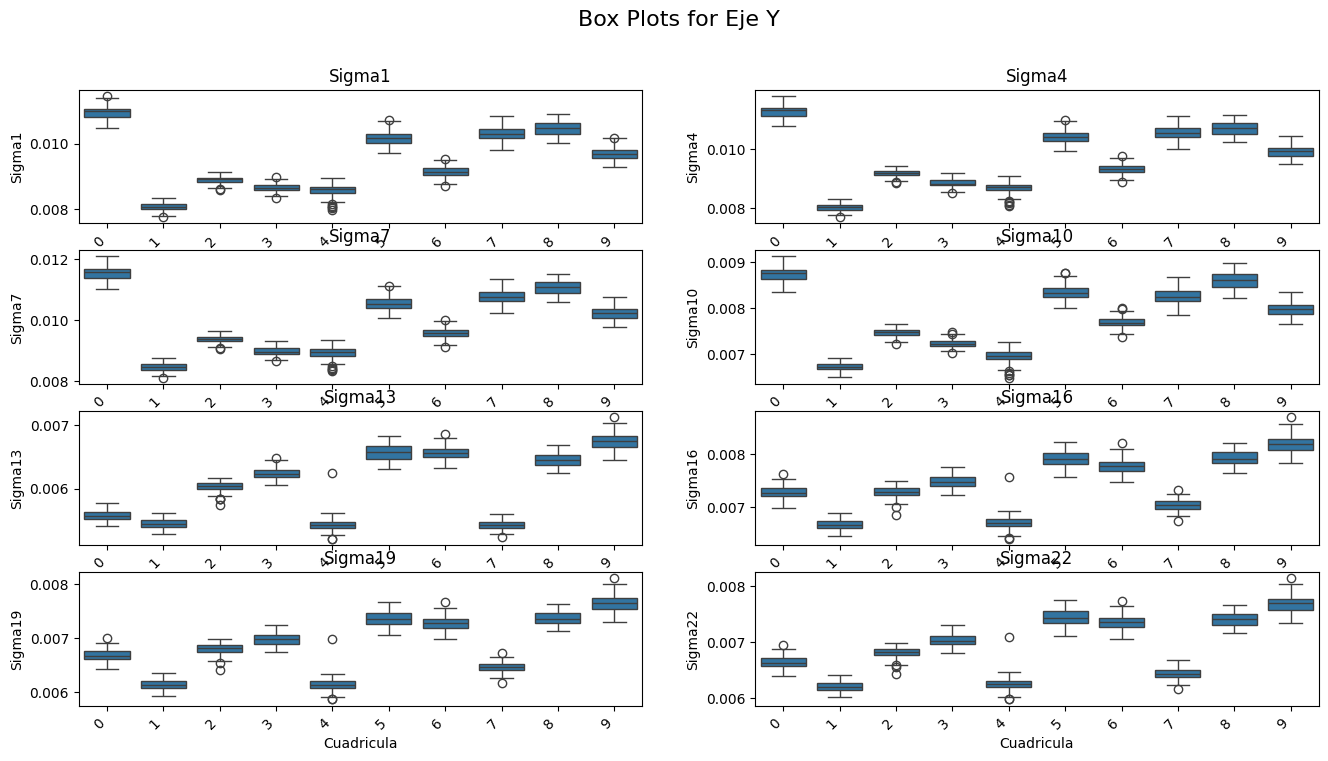

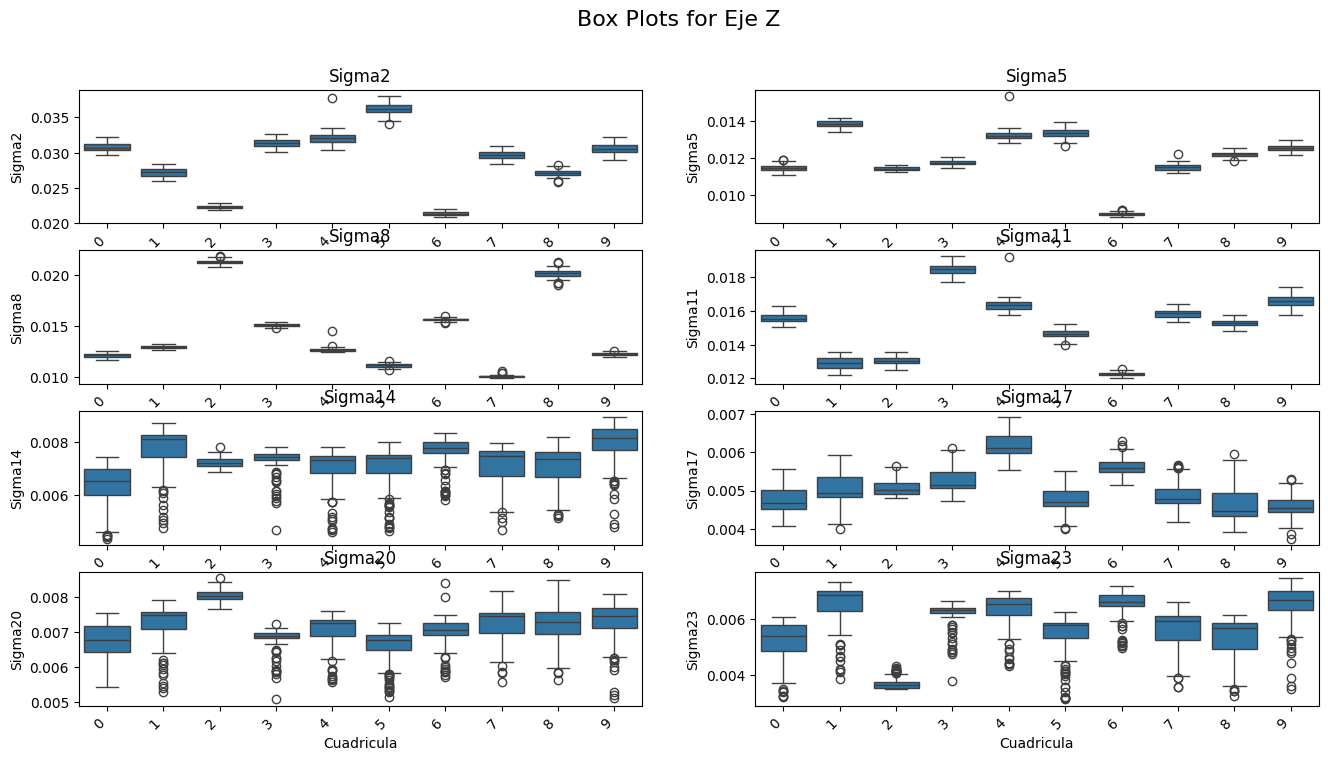

In [15]:
num_cols = ['Sigma' + str(i) for i in range(24)]  # Sigma0 to Sigma23
num_rows = 4  # Rows in the grid (changed to 3)
num_cols_grid = 2  # Columns in the grid (changed to 3)

# Dictionary for subtitles
subtitle_dict = {
    0: 'Eje X',
    3: 'Eje Y',
    6: 'Eje Z'
}

# Select specific columns for each subtitle
eje_x_cols = [num_cols[i] for i in range(0, 24, 3)]
eje_y_cols = [num_cols[i] for i in range(1, 24, 3)]
eje_z_cols = [num_cols[i] for i in range(2, 24, 3)]

create_plots(eje_x_cols, 'Eje X')
create_plots(eje_y_cols, 'Eje Y')
create_plots(eje_z_cols, 'Eje Z')

### Evolution over time

In [16]:
for k in range(3):
  # Select columns for plotting
  f_cols = ['Sigma' + str(i) for i in range(k, 24, 3)]  # f0 to f8
  plot_cols = ['Fecha'] + f_cols
  plot_df = data[plot_cols]

  # Melt the DataFrame for Plotly Express
  plot_df_melted = pd.melt(plot_df, id_vars=['Fecha'], value_vars=f_cols,
                        var_name='Sensor', value_name='Valor')

  # Create the interactive plot with points only
  fig = px.scatter(plot_df_melted, x='Fecha', y='Valor', color='Sensor',
                  title=f'Evolution of RMSE Values over Time ({subtitle_dict[k*3]})',
                  symbol='Sensor')  # Use symbol for different markers

  # Customize the appearance
  fig.update_traces(mode='markers',  # Set mode to 'markers' for points only
                  marker=dict(size=4))  # Adjust marker size as needed

  fig.update_layout(yaxis_title="")
  fig.show()

### Correlations

In [17]:
# Create correlation matrices and plots
def plot_correlation_matrix(data, columns, title):
    plt.figure(figsize=(12, 10))
    sns.heatmap(data[columns].corr(), annot=True, cmap='coolwarm')
    plt.title(title)
    plt.show()

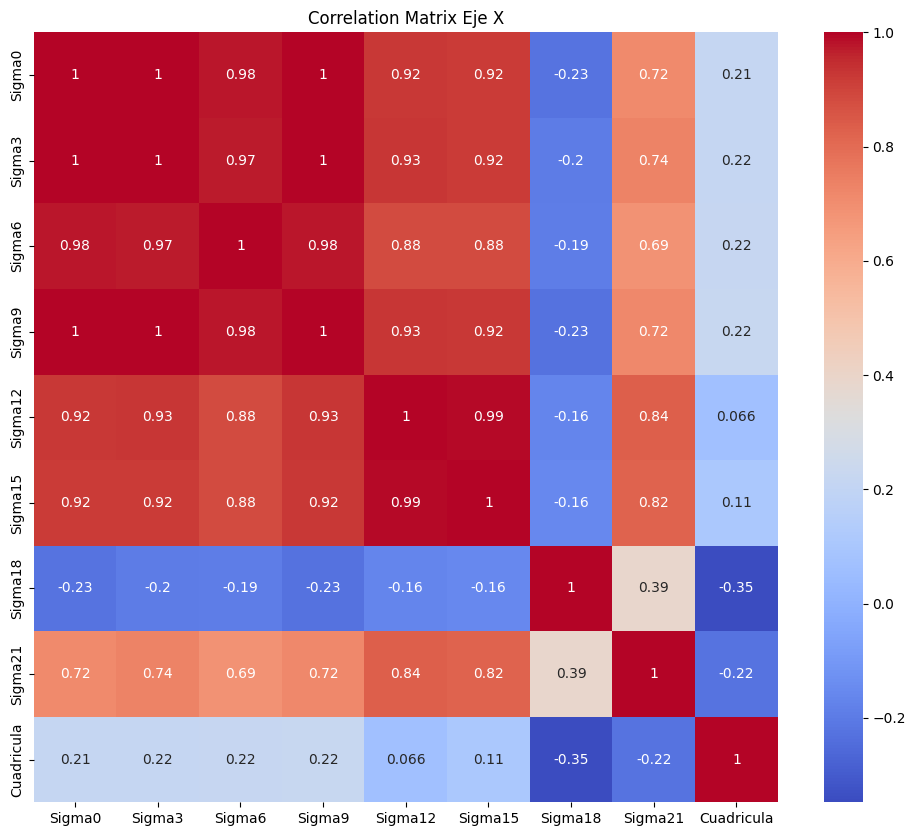

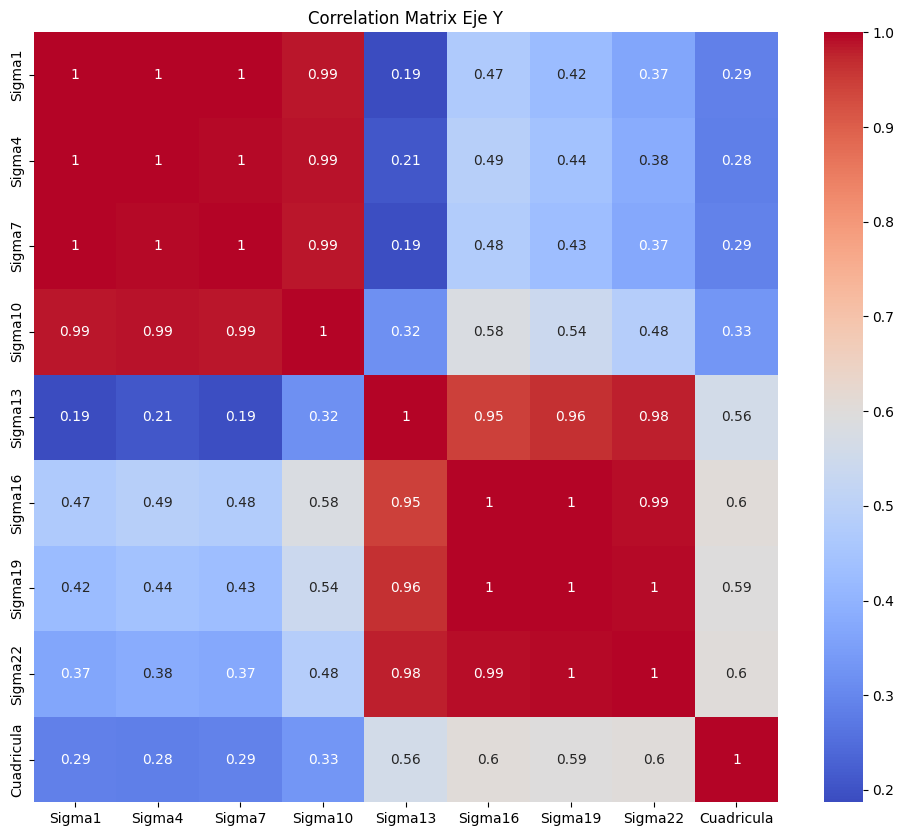

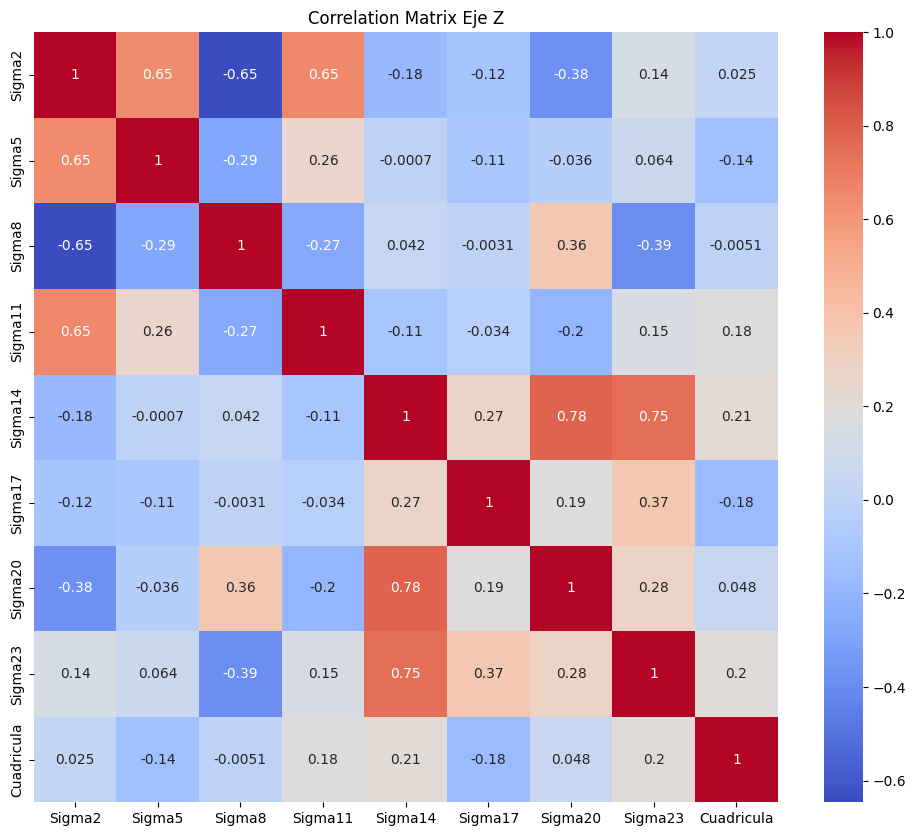

In [18]:
for k in range(3):
  # Define column groups
  sigma_group = ['Sigma' + str(i) for i in range(k, 24, 3)]  # Sigma0, Sigma3...
  sigma_group.append('Cuadricula')

  plot_correlation_matrix(data, sigma_group, f'Correlation Matrix {subtitle_dict[k*3]}')

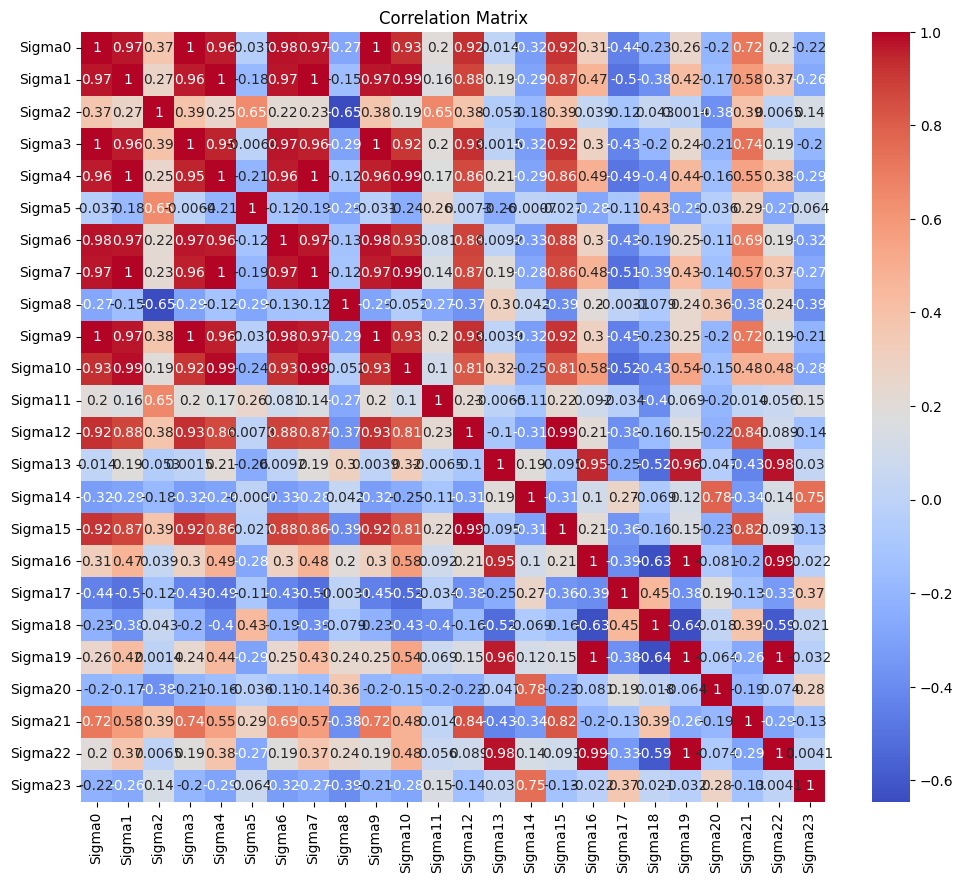

In [19]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(data.drop(columns=['Cuadricula', 'Peso', 'Fecha']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()